In [11]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import minimize
%matplotlib notebook

linear_data = np.arange(1, 31)

# исходная функция
def my_function(x):
    return math.sin(x / 5.) * math.exp(x / 10.) + 5 * math.exp(-x / 2.)

# функция для построения исходной функции
def original(data):
    return np.array([my_function(x) for x in data])

#### Задача 1. Минимизация гладкой функции

<IPython.core.display.Javascript object>


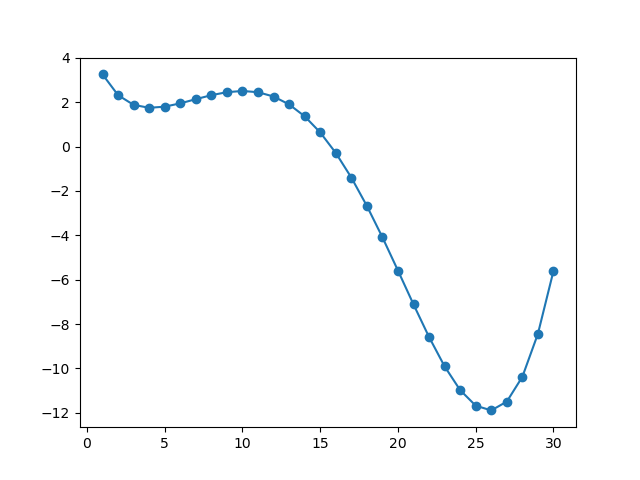

In [38]:
plt.figure()
plt.plot(linear_data, original(linear_data), '-o')

In [55]:
y1 = minimize(my_function, 2, method='BFGS')
y1

      fun: 1.7452682903447336
 hess_inv: array([[5.98752645]])
      jac: array([-2.04145908e-06])
  message: 'Optimization terminated successfully.'
     nfev: 14
      nit: 6
     njev: 7
   status: 0
  success: True
        x: array([4.13627628])

In [56]:
y2 = minimize(my_function, 30, method='BFGS')
y2

      fun: -11.898894665981313
 hess_inv: array([[1.67936744]])
      jac: array([0.])
  message: 'Optimization terminated successfully.'
     nfev: 14
      nit: 6
     njev: 7
   status: 0
  success: True
        x: array([25.88019321])

In [58]:
print(y1['fun'], y2['fun'])

1.7452682903447336 -11.898894665981313


#### Задача 2. Глобальная оптимизация

In [59]:
from scipy.optimize import differential_evolution
y3 = differential_evolution(my_function, [(1, 30)])
y3

     fun: -11.898894665981317
     jac: array([0.])
 message: 'Optimization terminated successfully.'
    nfev: 113
     nit: 6
 success: True
       x: array([25.88019317])

In [60]:
print(y3['fun'])

-11.898894665981317


#### Задача 3. Минимизация негладкой функции

In [40]:
# исходная функция
def my_function_2(x):
    return int(my_function(x))

# функция для построения исходной функции
def original_2(data):
    return np.array([my_function_2(x) for x in data])

<IPython.core.display.Javascript object>


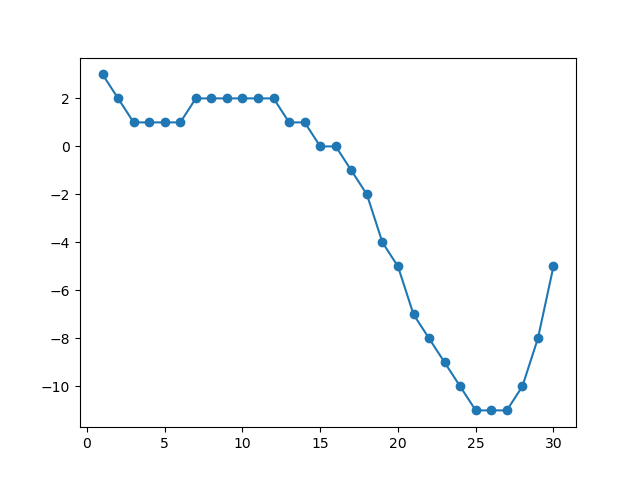

In [44]:
plt.figure()
plt.plot(linear_data, original_2(linear_data), '-o')

In [61]:
y4 = minimize(my_function_2, 30, method='BFGS')
y4

      fun: -5
 hess_inv: array([[1]])
      jac: array([0.])
  message: 'Optimization terminated successfully.'
     nfev: 2
      nit: 0
     njev: 1
   status: 0
  success: True
        x: array([30.])

In [62]:
y5 = differential_evolution(my_function_2, [(1, 30)])
y5

     fun: -11.0
 message: 'Optimization terminated successfully.'
    nfev: 77
     nit: 4
 success: True
       x: array([25.20813989])

In [63]:
print(y4['fun'], y5['fun'])

-5 -11.0
